In [360]:
import sys
import os
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../analysisFunctions'))
sys.path.insert(0, dir1)
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from machine_learning import *
from sklearn.pipeline import Pipeline

In [361]:
myPredictorsDf = pd.read_csv('..\predictorsDF.csv')
myPredictorsDf

,SUBJID,groupe,CPC_SC3,J0_SEX,J0_TAILLE,J0_POIDS,J0_BMI,J0_AGE,J0_PAS,J0_PAD,...,EI_CONVULS,EI_ARYTHMI,EI_ANTIEPILEPTIQ,BARTHEL_SC,SOFA_SC7,SOFA_SC1,DS_DC,DAYS_ALIVE_30,CPC12,SEX
0,1001,1.0,5.0,Femme,150.0,70.0,31.1,84.0,95.0,42.0,...,NaN,NaN,NaN,NaN,7.0,11.0,1.0,7.0,0,0
1,1002,0.0,5.0,Femme,163.0,94.0,35.4,75.0,130.0,68.0,...,NaN,NaN,NaN,NaN,NaN,14.0,1.0,-139.0,0,0
2,1003,0.0,5.0,Homme,167.0,78.0,28.0,75.0,144.0,80.0,...,10.0,0.0,0.0,NaN,NaN,11.0,1.0,3.0,0,1
3,1004,0.0,3.0,Femme,159.0,34.0,13.4,50.0,143.0,82.0,...,NaN,NaN,NaN,80.0,7.0,16.0,0.0,30.0,0,0
4,1005,0.0,5.0,Homme,179.0,105.0,32.8,63.0,195.0,104.0,...,NaN,NaN,NaN,NaN,NaN,9.0,1.0,2.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
576,26010,0.0,5.0,Homme,167.0,63.0,22.6,70.0,114.0,52.0,...,0.0,0.0,NaN,NaN,NaN,18.0,1.0,3.0,0,1
577,26011,1.0,5.0,Homme,NaN,82.0,NaN,68.0,127.0,71.0,...,NaN,NaN,NaN,NaN,2.0,12.0,0.0,30.0,0,1
578,26012,0.0,5.0,Homme,167.0,72.0,25.8,78.0,102.0,57.0,...,NaN,NaN,NaN,NaN,6.0,11.0,1.0,30.0,0,1
579,26014,0.0,5.0,Femme,146.0,71.0,33.3,82.0,226.0,104.0,...,1.0,0.0,1.0,NaN,NaN,10.0,1.0,2.0,0,0


In [362]:
X = myPredictorsDf.drop(['SUBJID','CPC_SC3','J0_SEX'],axis=1)
X

,groupe,J0_TAILLE,J0_POIDS,J0_BMI,J0_AGE,J0_PAS,J0_PAD,J0_PAM,J0_FC,J0_SPO2,...,EI_CONVULS,EI_ARYTHMI,EI_ANTIEPILEPTIQ,BARTHEL_SC,SOFA_SC7,SOFA_SC1,DS_DC,DAYS_ALIVE_30,CPC12,SEX
0,1.0,150.0,70.0,31.1,84.0,95.0,42.0,54.0,59.0,92.0,...,NaN,NaN,NaN,NaN,7.0,11.0,1.0,7.0,0,0
1,0.0,163.0,94.0,35.4,75.0,130.0,68.0,83.0,86.0,96.0,...,NaN,NaN,NaN,NaN,NaN,14.0,1.0,-139.0,0,0
2,0.0,167.0,78.0,28.0,75.0,144.0,80.0,95.0,119.0,71.0,...,10.0,0.0,0.0,NaN,NaN,11.0,1.0,3.0,0,1
3,0.0,159.0,34.0,13.4,50.0,143.0,82.0,63.0,87.0,100.0,...,NaN,NaN,NaN,80.0,7.0,16.0,0.0,30.0,0,0
4,0.0,179.0,105.0,32.8,63.0,195.0,104.0,133.0,85.0,91.0,...,NaN,NaN,NaN,NaN,NaN,9.0,1.0,2.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
576,0.0,167.0,63.0,22.6,70.0,114.0,52.0,67.0,112.0,93.0,...,0.0,0.0,NaN,NaN,NaN,18.0,1.0,3.0,0,1
577,1.0,NaN,82.0,NaN,68.0,127.0,71.0,90.0,59.0,100.0,...,NaN,NaN,NaN,NaN,2.0,12.0,0.0,30.0,0,1
578,0.0,167.0,72.0,25.8,78.0,102.0,57.0,71.0,132.0,99.0,...,NaN,NaN,NaN,NaN,6.0,11.0,1.0,30.0,0,1
579,0.0,146.0,71.0,33.3,82.0,226.0,104.0,153.0,109.0,77.0,...,1.0,0.0,1.0,NaN,NaN,10.0,1.0,2.0,0,0


In [363]:
pipe = Pipeline(getDefaultPipelineSteps(X))
pipe

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder=OneHotEncoder(handle_unknown='ignore'),
                                   transformers=[('num', StandardScaler(),
                                                  Index(['J0_TAILLE', 'J0_POIDS', 'J0_BMI', 'J0_AGE', 'J0_PAS', 'J0_PAD',
       'J0_PAM', 'J0_FC', 'J0_SPO2', 'J0_TEMP', 'J0_IGSII', 'J0_CHARLSON',
       'J0_NOFLOW', 'J0_LOWFLOW', 'J0_ADRE_DOS', 'J0_PEP', 'J0_FIO2', 'J0_VT',
       'J0_FR', 'BIO_LEUCO'...
       'J0_AMINE', 'J0_NORA', 'J0_ADRE2', 'J0_DOBU', 'J0_DOPA', 'ECG',
       'ECG_ANOMALI', 'ECG_SUS_ST', 'ECG_SOUS_ST', 'ECG_BAVI', 'ECG_BAVII',
       'ECG_BAVIII', 'ECG_BBG', 'ECG_BBD', 'ECG_TACHICARD', 'ECG_FIBRIL',
       'ECG_SALV_VENT', 'ECG_FLUTER', 'ECG_SALV_SUPRA', 'EI_EI',
       'EI_HEMOSEVER', 'EI_TRANSFUS', 'EI_INTRACER', 'EI_CHIR', 'EI_ECHO',
       'EI_DIURETIQ', 'EI_ANTIEPILEPTIQ', 'DS_DC', 'CPC12', 'SEX'],
      dtype='object'))])),
                ('imputer', SimpleImputer())])

In [364]:
X_scaled = pd.DataFrame(pipe.fit_transform(X))
new_columns = pipe.named_steps['preprocessor'].get_feature_names_out()
X_scaled.columns = new_columns
X_scaled

,num__J0_TAILLE,num__J0_POIDS,num__J0_BMI,num__J0_AGE,num__J0_PAS,num__J0_PAD,num__J0_PAM,num__J0_FC,num__J0_SPO2,num__J0_TEMP,...,remainder__EI_CONVULS_3.0,remainder__EI_CONVULS_5.0,remainder__EI_CONVULS_10.0,remainder__EI_CONVULS_nan,remainder__EI_ARYTHMI_0.0,remainder__EI_ARYTHMI_1.0,remainder__EI_ARYTHMI_2.0,remainder__EI_ARYTHMI_3.0,remainder__EI_ARYTHMI_5.0,remainder__EI_ARYTHMI_nan
0,-2.003571e+00,-0.464342,4.178351e-01,1.374153,-0.825519,-1.292740,-1.307486,-1.431473,-1.236474,1.110486e+00,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-5.650079e-01,0.731513,1.032158e+00,0.712679,0.374913,0.079389,0.070755,-0.258981,-0.255852,-6.148627e-01,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-1.223731e-01,-0.065724,-2.504896e-02,0.712679,0.855086,0.712680,0.641061,1.174064,-6.384742,-2.830650e-01,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,-1.007643e+00,-2.258126,-2.110890e+00,-1.124747,0.820788,0.818228,-0.879756,-0.215556,0.724771,-2.804728e+00,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.205531e+00,1.279614,6.607070e-01,-0.169285,2.604288,1.979261,2.447032,-0.302407,-1.481630,2.478115e-01,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
576,-1.223731e-01,-0.813133,-7.965244e-01,0.345194,-0.173856,-0.764998,-0.689654,0.870085,-0.991319,4.468901e-01,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
577,-7.874398e-16,0.133585,-5.259339e-16,0.198200,0.272019,0.237712,0.403434,-1.431473,0.724771,-1.917930e-15,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
578,-1.223731e-01,-0.364688,-3.393538e-01,0.933171,-0.585433,-0.501127,-0.499552,1.738597,0.479615,1.044126e+00,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
579,-2.446206e+00,-0.414515,7.321399e-01,1.227159,3.667529,1.979261,3.397543,0.739808,-4.913808,7.123283e-01,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


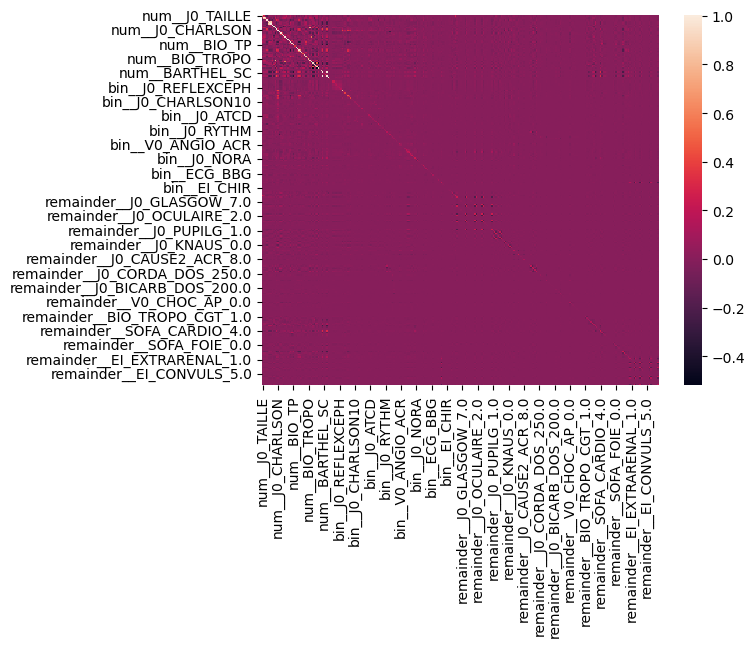

In [365]:
c = X_scaled.cov()
sns.heatmap(c)
plt.show()

In [366]:
eigenvalues, eigenvectors = np.linalg.eig(c)
explained_var = np.cumsum(eigenvalues) / np.sum(eigenvalues)

c:\Program Files\miniconda3\lib\site-packages\matplotlib\cbook\__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


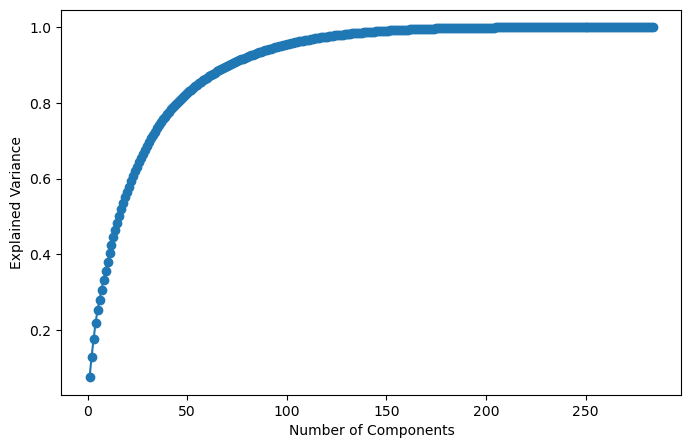

In [367]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_var) + 1), explained_var, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance')
plt.show()

In [368]:
n_components = np.argmax(explained_var >= 0.9) + 1
n_components

71

In [369]:
u = eigenvectors[:,:n_components]
pca_component = pd.DataFrame(u, index = X_scaled.columns)
pca_component

,0,1,2,3,4,5,6,7,8,9,...,61,62,63,64,65,66,67,68,69,70
num__J0_TAILLE,-0.033454+0.000000j,-0.073874+0.000000j,0.145682+0.000000j,0.013451+0.000000j,-0.031445+0.000000j,-0.245645+0.000000j,0.072147+0.000000j,-0.136988+0.000000j,-0.237163+0.000000j,-0.331249+0.000000j,...,-0.009355+0.000000j,-0.002019+0.000000j,-0.016347+0.000000j,-0.037807+0.000000j,0.012816+0.000000j,0.004240+0.000000j,0.014068+0.000000j,-0.046960+0.000000j,-0.044730+0.000000j,0.111361+0.000000j
num__J0_POIDS,0.074919+0.000000j,-0.205789+0.000000j,0.243502+0.000000j,-0.118644+0.000000j,-0.301103+0.000000j,-0.298357+0.000000j,0.136806+0.000000j,0.191991+0.000000j,0.024017+0.000000j,-0.050964+0.000000j,...,-0.000540+0.000000j,-0.007542+0.000000j,-0.044643+0.000000j,0.025326+0.000000j,0.000863+0.000000j,0.015322+0.000000j,-0.019926+0.000000j,0.007371+0.000000j,-0.034644+0.000000j,0.007155+0.000000j
num__J0_BMI,0.087321+0.000000j,-0.169573+0.000000j,0.181973+0.000000j,-0.124142+0.000000j,-0.284958+0.000000j,-0.181069+0.000000j,0.101012+0.000000j,0.258143+0.000000j,0.140905+0.000000j,0.094720+0.000000j,...,-0.004565+0.000000j,-0.013953+0.000000j,-0.007910+0.000000j,0.022500+0.000000j,-0.020896+0.000000j,-0.031351+0.000000j,-0.000357+0.000000j,0.003460+0.000000j,-0.010944+0.000000j,-0.045737+0.000000j
num__J0_AGE,0.135590+0.000000j,-0.025961+0.000000j,-0.185993+0.000000j,-0.170051+0.000000j,-0.081517+0.000000j,0.007511+0.000000j,-0.013726+0.000000j,0.118623+0.000000j,0.153322+0.000000j,0.163067+0.000000j,...,-0.046181+0.000000j,0.044695+0.000000j,0.031956+0.000000j,0.120693+0.000000j,0.000411+0.000000j,0.062887+0.000000j,0.035803+0.000000j,0.004694+0.000000j,0.017587+0.000000j,-0.026826+0.000000j
num__J0_PAS,-0.170703+0.000000j,0.024651+0.000000j,0.135448+0.000000j,-0.376441+0.000000j,0.277020+0.000000j,0.036059+0.000000j,0.096216+0.000000j,0.085373+0.000000j,0.047115+0.000000j,0.008953+0.000000j,...,-0.091437+0.000000j,-0.004711+0.000000j,-0.073383+0.000000j,-0.067131+0.000000j,0.077478+0.000000j,-0.014218+0.000000j,-0.049621+0.000000j,-0.109650+0.000000j,0.106724+0.000000j,0.032384+0.000000j
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
remainder__EI_ARYTHMI_1.0,0.006378+0.000000j,0.001921+0.000000j,0.002910+0.000000j,0.004677+0.000000j,0.010265+0.000000j,-0.009331+0.000000j,-0.004322+0.000000j,0.014434+0.000000j,-0.014676+0.000000j,0.022123+0.000000j,...,0.010233+0.000000j,-0.021782+0.000000j,-0.025602+0.000000j,0.039320+0.000000j,0.015871+0.000000j,-0.005093+0.000000j,-0.012774+0.000000j,-0.017184+0.000000j,0.011670+0.000000j,-0.017781+0.000000j
remainder__EI_ARYTHMI_2.0,0.002052+0.000000j,-0.003960+0.000000j,0.001837+0.000000j,0.001951+0.000000j,0.001922+0.000000j,-0.000148+0.000000j,-0.001162+0.000000j,0.003693+0.000000j,-0.000170+0.000000j,0.001368+0.000000j,...,0.003526+0.000000j,0.003462+0.000000j,-0.005256+0.000000j,-0.001036+0.000000j,0.014081+0.000000j,0.002364+0.000000j,0.020129+0.000000j,0.000439+0.000000j,0.008205+0.000000j,0.005801+0.000000j
remainder__EI_ARYTHMI_3.0,0.001503+0.000000j,-0.000386+0.000000j,-0.001115+0.000000j,0.000043+0.000000j,0.001529+0.000000j,-0.000446+0.000000j,-0.002261+0.000000j,-0.000030+0.000000j,0.001148+0.000000j,0.002454+0.000000j,...,-0.003526+0.000000j,-0.005654+0.000000j,-0.008062+0.000000j,-0.002814+0.000000j,0.000476+0.000000j,-0.008593+0.000000j,0.005133+0.000000j,-0.003692+0.000000j,-0.000887+0.000000j,-0.000867+0.000000j
remainder__EI_ARYTHMI_5.0,-0.000277+0.000000j,0.000541+0.000000j,0.001923+0.000000j,0.001111+0.000000j,-0.000156+0.000000j,0.001506+0.000000j,-0.000770+0.000000j,0.000449+0.000000j,-0.002112+0.000000j,-0.000482+0.000000j,...,0.009229+0.000000j,-0.005298+0.000000j,-0.003151+0.000000j,0.005492+0.000000j,-0.006876+0.000000j,-0.004184+0.000000j,-0.003718+0.000000j,0.005869+0.000000j,0.007242+0.000000j,-0.001129+0.000000j


In [370]:
(pca_component.applymap(lambda x: x.imag != 0)).any().any()

False

In [371]:
pca_component = pca_component.applymap(lambda x: x.real)
pca_component

,0,1,2,3,4,5,6,7,8,9,...,61,62,63,64,65,66,67,68,69,70
num__J0_TAILLE,-0.033454,-0.073874,0.145682,0.013451,-0.031445,-0.245645,0.072147,-0.136988,-0.237163,-0.331249,...,-0.009355,-0.002019,-0.016347,-0.037807,0.012816,0.004240,0.014068,-0.046960,-0.044730,0.111361
num__J0_POIDS,0.074919,-0.205789,0.243502,-0.118644,-0.301103,-0.298357,0.136806,0.191991,0.024017,-0.050964,...,-0.000540,-0.007542,-0.044643,0.025326,0.000863,0.015322,-0.019926,0.007371,-0.034644,0.007155
num__J0_BMI,0.087321,-0.169573,0.181973,-0.124142,-0.284958,-0.181069,0.101012,0.258143,0.140905,0.094720,...,-0.004565,-0.013953,-0.007910,0.022500,-0.020896,-0.031351,-0.000357,0.003460,-0.010944,-0.045737
num__J0_AGE,0.135590,-0.025961,-0.185993,-0.170051,-0.081517,0.007511,-0.013726,0.118623,0.153322,0.163067,...,-0.046181,0.044695,0.031956,0.120693,0.000411,0.062887,0.035803,0.004694,0.017587,-0.026826
num__J0_PAS,-0.170703,0.024651,0.135448,-0.376441,0.277020,0.036059,0.096216,0.085373,0.047115,0.008953,...,-0.091437,-0.004711,-0.073383,-0.067131,0.077478,-0.014218,-0.049621,-0.109650,0.106724,0.032384
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
remainder__EI_ARYTHMI_1.0,0.006378,0.001921,0.002910,0.004677,0.010265,-0.009331,-0.004322,0.014434,-0.014676,0.022123,...,0.010233,-0.021782,-0.025602,0.039320,0.015871,-0.005093,-0.012774,-0.017184,0.011670,-0.017781
remainder__EI_ARYTHMI_2.0,0.002052,-0.003960,0.001837,0.001951,0.001922,-0.000148,-0.001162,0.003693,-0.000170,0.001368,...,0.003526,0.003462,-0.005256,-0.001036,0.014081,0.002364,0.020129,0.000439,0.008205,0.005801
remainder__EI_ARYTHMI_3.0,0.001503,-0.000386,-0.001115,0.000043,0.001529,-0.000446,-0.002261,-0.000030,0.001148,0.002454,...,-0.003526,-0.005654,-0.008062,-0.002814,0.000476,-0.008593,0.005133,-0.003692,-0.000887,-0.000867
remainder__EI_ARYTHMI_5.0,-0.000277,0.000541,0.001923,0.001111,-0.000156,0.001506,-0.000770,0.000449,-0.002112,-0.000482,...,0.009229,-0.005298,-0.003151,0.005492,-0.006876,-0.004184,-0.003718,0.005869,0.007242,-0.001129


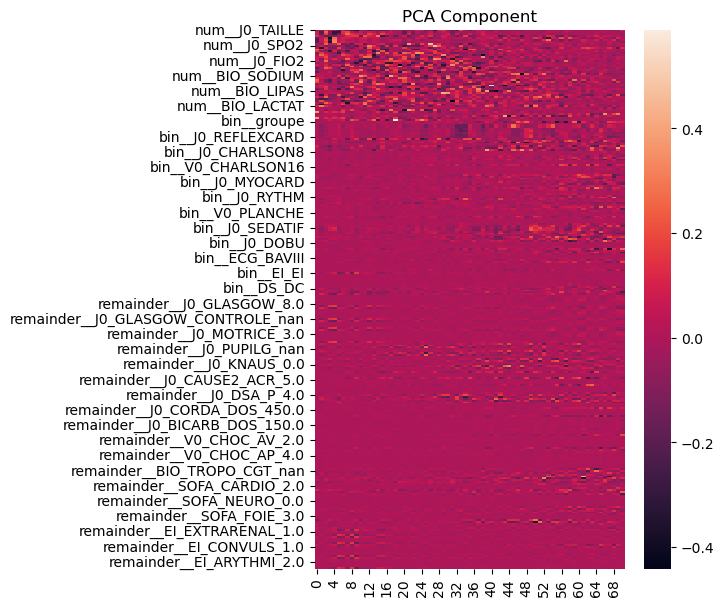

In [372]:
plt.figure(figsize =(5, 7))
sns.heatmap(pca_component)
plt.title('PCA Component')
plt.show()

In [373]:
# X_pca = X_scaled @ pca_components
pca = PCA(n_components=71)
X_pca = pd.DataFrame(pca.fit_transform(X_scaled))
X_pca

,0,1,2,3,4,5,6,7,8,9,...,61,62,63,64,65,66,67,68,69,70
0,0.745531,-2.104172,0.920474,-0.727725,1.899389,2.838589,1.606475,-0.892557,1.653563,2.152228,...,0.391994,-0.016147,-0.217938,-0.011065,-0.080034,0.169902,-0.672160,-0.356183,-0.139384,-0.334570
1,3.220847,-1.245213,0.626440,2.413800,-0.160247,0.245971,0.410620,-0.794224,1.901655,-0.153826,...,-0.432639,-0.720473,0.325695,-0.218616,-0.049121,-0.232231,-0.026831,0.516464,-0.620690,-0.430274
2,0.330829,-1.059304,-3.021731,0.309561,-1.651350,0.315035,1.398718,-2.139269,0.357984,3.380378,...,-0.201455,-0.143474,-0.821594,0.309506,-0.635052,-1.107691,-0.344443,-0.075264,-0.448028,0.316436
3,5.958302,3.060840,4.110040,3.116789,-3.861293,-0.754371,2.075940,1.203298,3.032583,-2.463565,...,1.143094,-0.485611,-0.292752,-0.139577,0.100530,1.235014,-0.472105,-0.895079,-0.553363,-0.018114
4,-1.667417,-1.080191,-3.949554,2.589913,-0.710479,-0.180967,-1.995310,0.820724,1.306517,0.195704,...,-0.367870,-0.600015,0.042741,1.101745,-0.210380,0.570126,0.266960,-0.179605,0.345551,-0.513099
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
576,4.933606,0.141626,-0.042283,0.121809,-2.493268,0.325793,-0.176415,2.360934,-1.219828,1.897145,...,0.551827,0.225035,0.494684,0.479861,0.430125,-0.501924,0.109436,0.886380,0.132094,-0.343553
577,-0.675991,-1.391865,0.395440,-0.997311,-0.517504,0.569279,-1.715220,0.773548,0.862986,0.159164,...,0.260801,0.508857,-0.174046,0.172561,0.098434,-0.206848,0.464169,-0.012185,-0.334186,0.370435
578,0.313074,-2.434594,1.379221,-0.801974,0.120720,1.595501,-0.150360,0.079275,-0.048649,-0.725316,...,0.370785,-0.008159,-0.402746,-0.207880,-0.018318,-0.479687,-0.652310,0.043852,0.305776,-0.044684
579,-1.225159,-0.358556,-1.027984,3.664816,-3.101833,1.867777,0.775731,-3.141651,-0.302732,3.650232,...,-0.142358,-0.083984,-0.330992,0.288308,-0.493929,0.351110,-0.662547,0.010052,-0.468106,-0.409825


In [374]:
explained_variance_ratio = pca.explained_variance_ratio_
total_explained_variance_ratio = explained_variance_ratio.sum()
print(total_explained_variance_ratio)

0.8998941193221414
